### 01 - Shadow Model

Trains the shadow model. Identical architecture and training procedure to notebook 00, run on shadow data instead of target data.

The attacker uses this to study how the model behaves on training data versus held-out data. Because the attacker controls the shadow's training set, they have ground-truth membership labels to learn from.

##### Inputs
- `data/external/BaselineDataSplits/shadow_{train,test}.csv`
- `data/external/clinicalbert/{x1,x2,y}_shadow_{train,test}.npy`

##### Outputs
- `outputs/models/shadow_encoder.h5`
- `outputs/models/shadow_clf.h5`


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import BertTokenizer, TFBertModel
import arff
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

2026-04-29 10:41:20.229285: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 10:41:20.231188: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-29 10:41:20.258493: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-29 10:41:20.258530: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-29 10:41:20.259405: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [3]:
# ==========================
# Step 1: Load data
# ===========================


train_df = pd.read_csv("data/external/BaselineDataSplits/shadow_train.csv")
test_df  = pd.read_csv("data/external/BaselineDataSplits/shadow_test.csv")

# sample_matching_df = pairwise_df[pairwise_df['label'] == 1].sample(n=50000, random_state=42)
# sample_nonmatching_df = pairwise_df[pairwise_df['label'] == 0].sample(n=50000, random_state=42)
# sample_df = pd.concat([sample_matching_df, sample_nonmatching_df]).reset_index(drop=True)

# # Optionally, print sample_df to inspect
# print("Sampled record pairs:")
# print(sample_df[['uid1', 'uid2', 'label']].head())

In [4]:
print(train_df.head())

        uid1                                              text1       uid2  \
0  6161574-1  A 39-year-old male presented with a history of...  7280936-1   
1  3355874-1  A 5.9-year-old male presented with short statu...  4124264-1   
2  5289268-1  A 92-year-old female with a history of hyperte...  5289268-5   
3  7069865-1  A 75-year-old man had a regular visit for COPD...  7069865-3   
4  4323975-1  We admitted a 6-year-old male child who presen...  5965193-1   

                                               text2  label  
0  A 28-year-old woman with generalized dystonia ...      0  
1  We report a 41-year-old male patient known to ...      0  
2  An 11-year-old female with no past medical his...      1  
3  An 89-year-old man with a history of COPD (GOL...      1  
4  A six-year-old female presented to a small rur...      0  


In [ ]:
# Step 3: Generate embeddings only for train and test separately
import numpy as np
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf
from tqdm import tqdm

# Load pretrained BERT model and tokenizer
from transformers import BertTokenizer, TFBertModel

# Load ClinicalBERT
tokenizer = BertTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
bert_model = TFBertModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")


# Helper function for batched embedding generation
def generate_embeddings_batched(texts, batch_size=32, max_length=512):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts.iloc[i:i+batch_size].tolist()
        inputs = tokenizer(
            batch,
            return_tensors="tf",
            padding=True,
            truncation=True,
            max_length=max_length  # Truncate to 512 tokens
        )
        outputs = bert_model(inputs["input_ids"])
        cls_embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        all_embeddings.append(cls_embeddings.numpy())

    return np.vstack(all_embeddings)
# Encode and save embeddings
x1_train = generate_embeddings_batched(train_df['text1'])
x2_train = generate_embeddings_batched(train_df['text2'])
y_train = train_df['label'].values.astype(np.float32)

x1_test = generate_embeddings_batched(test_df['text1'])
x2_test = generate_embeddings_batched(test_df['text2'])
y_test = test_df['label'].values.astype(np.float32)

Exception ignored in: <function WeakValueDictionary.__init__.<locals>.remove at 0x73da7a28ff60>
Traceback (most recent call last):
  File "/nix/store/5bd4b8iifahkr4di8np8pirmcsmcvlgh-python3-3.11.15/lib/python3.11/weakref.py", line 105, in remove
    def remove(wr, selfref=ref(self), _atomic_removal=_remove_dead_weakref):

KeyboardInterrupt: 
Some layers from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT were not used when initializing TFBertModel: ['mlm___cls', 'nsp___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from t

KeyboardInterrupt: 

In [ ]:
# Directory to store cached files
# os.makedirs("clinicalbert", exist_ok=True)
# # save the embeddings for later use
np.save("data/local/clinicalbert/x1_shadow_train.npy", x1_train)
np.save("data/local/clinicalbert/x2_shadow_train.npy", x2_train)
np.save("data/local/clinicalbert/y_shadow_train.npy", y_train)
np.save("data/local/clinicalbert/x1_shadow_test.npy", x1_test)
np.save("data/local/clinicalbert/x2_shadow_test.npy", x1_test)
np.save("cclinicalbert/y_shadow_test.npy", y_test)

In [5]:


# For the later experiments load the embeddings using following code
x1_train = np.load("data/external/clinicalbert/x1_shadow_train.npy")
x2_train = np.load("data/external/clinicalbert/x2_shadow_train.npy")
y_train  = np.load("data/external/clinicalbert/y_shadow_train.npy")
x1_test  = np.load("data/external/clinicalbert/x1_shadow_test.npy")
x2_test  = np.load("data/external/clinicalbert/x2_shadow_test.npy")
y_test   = np.load("data/external/clinicalbert/y_shadow_test.npy")

In [6]:
# ====================================
# Step 3: Build Siamese Autoencoder
# ====================================
from tensorflow.keras import layers, regularizers, Model, Input


def build_siamese_autoencoder(embedding_dim):
    encoder_input = Input(shape=(embedding_dim,))
    x = layers.Dense(50, activity_regularizer=regularizers.l1(0.01))(encoder_input)
    x = layers.LeakyReLU(alpha=0.01)(x)
    encoder_output = layers.Dense(embedding_dim)(x)  # Consider linear output
    encoder = Model(encoder_input, encoder_output)

    decoder_input = Input(shape=(embedding_dim,))
    decoder_output = layers.Dense(embedding_dim, activation='sigmoid')(decoder_input)
    decoder = Model(decoder_input, decoder_output)

    input1 = Input(shape=(embedding_dim,))
    input2 = Input(shape=(embedding_dim,))
    encoded1 = encoder(input1)
    encoded2 = encoder(input2)
    recon1 = decoder(encoded1)
    recon2 = decoder(encoded2)

    # Output both encoded and reconstructed vectors
    merged_output = layers.Concatenate()([encoded1, encoded2, recon1, recon2])
    model = Model(inputs=[input1, input2], outputs=merged_output)
    return model, encoder

def hybrid_classification_loss(margin=2.5, alpha=1.0):
    def loss_fn(y_true, y_pred):
        emb_dim = tf.shape(y_pred)[1] // 4
        encoded1 = y_pred[:, :emb_dim]
        encoded2 = y_pred[:, emb_dim:2*emb_dim]
        recon1 = y_pred[:, 2*emb_dim:3*emb_dim]
        recon2 = y_pred[:, 3*emb_dim:]

        # Contrastive loss on encoded vectors
        distances = tf.norm(encoded1 - encoded2, axis=1)
        y_true = tf.cast(y_true, tf.float32)
        contrastive_loss = y_true * tf.square(distances) + (1 - y_true) * tf.square(tf.maximum(margin - distances, 0))

        # True reconstruction loss: input1 vs recon1, input2 vs recon2
        recon_loss1 = tf.reduce_mean(tf.square(encoded1 - recon1), axis=1)
        recon_loss2 = tf.reduce_mean(tf.square(encoded2 - recon2), axis=1)
        recon_loss = 0.5 * (recon_loss1 + recon_loss2)

        return tf.reduce_mean(alpha * recon_loss + contrastive_loss)
    return loss_fn

embedding_dim = x1_train.shape[1]
sa_model, encoder = build_siamese_autoencoder(embedding_dim)
sa_model.compile(optimizer='adam', loss=hybrid_classification_loss(margin=2.5, alpha=1.0))
sa_model.fit([x1_train, x2_train], y_train, epochs=30, batch_size=256, validation_split=0.1)

Epoch 1/30
113/113 [==============================] - 2s 10ms/step - loss: 1.8788 - val_loss: 1.7815
Epoch 2/30
113/113 [==============================] - 1s 8ms/step - loss: 1.7402 - val_loss: 1.7401
Epoch 3/30
113/113 [==============================] - 1s 9ms/step - loss: 1.7216 - val_loss: 1.7490
Epoch 4/30
113/113 [==============================] - 1s 8ms/step - loss: 1.7178 - val_loss: 1.7100
Epoch 5/30
113/113 [==============================] - 1s 8ms/step - loss: 1.7187 - val_loss: 1.7126
Epoch 6/30
113/113 [==============================] - 1s 8ms/step - loss: 1.6988 - val_loss: 1.6888
Epoch 7/30
113/113 [==============================] - 1s 9ms/step - loss: 1.7033 - val_loss: 1.7173
Epoch 8/30
113/113 [==============================] - 1s 9ms/step - loss: 1.7134 - val_loss: 1.6896
Epoch 9/30
113/113 [==============================] - 1s 9ms/step - loss: 1.7035 - val_loss: 1.7236
Epoch 10/30
113/113 [==============================] - 1s 9ms/step - loss: 1.7013 - val_loss: 1.830

In [7]:
# ==========================================================
# Evaluate the Siamese Autoencoder (Threshold-based)
# ==========================================================

# Get reconstructions
encoded1_train = encoder.predict(x1_train)
encoded2_train = encoder.predict(x2_train)
encoded1_test = encoder.predict(x1_test)
encoded2_test = encoder.predict(x2_test)

# Compute Euclidean distances
train_distances = np.sqrt(np.sum((encoded1_train - encoded2_train)**2, axis=1))
test_distances = np.sqrt(np.sum((encoded1_test - encoded2_test)**2, axis=1))

# Use fixed threshold (e.g., 1.0) to classify matches
threshold = 1.0
train_pred = (train_distances < threshold).astype(int)
test_pred = (test_distances < threshold).astype(int)

# Accuracy & F1
train_acc = accuracy_score(y_train, train_pred)
train_f1 = f1_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)

print("------ Siamese Autoencoder Evaluation ------")
print(f"Training Accuracy: {train_acc:.4f}, F1 Score: {train_f1:.4f}")
print(f"Test Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}")


250/250 [==============================] - 0s 436us/step
------ Siamese Autoencoder Evaluation ------
Training Accuracy: 0.5995, F1 Score: 0.3739
Test Accuracy: 0.6202, F1 Score: 0.4617


In [8]:
# ====================================
# Step 4: Add Classification Head
'''
A small feed-forward network (MLP) takes the difference vector as input.
Learns non-linear interactions between embedding dimensions.
Outputs a probability of match using sigmoid
'''
# ====================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate

# Step 1: Get encoded outputs
encoded1_train = encoder.predict(x1_train)
encoded2_train = encoder.predict(x2_train)
encoded1_test = encoder.predict(x1_test)
encoded2_test = encoder.predict(x2_test)

# Step 2: Compute absolute differences (Siamese-style)
diff_train = np.abs(encoded1_train - encoded2_train)
diff_test = np.abs(encoded1_test - encoded2_test)

# Step 3: Build classification model
input_diff = Input(shape=(diff_train.shape[1],))
x = Dense(64, activation='relu')(input_diff)
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)
clf_model = Model(inputs=input_diff, outputs=output)

clf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 4: Train the classifier
clf_model.fit(diff_train, y_train, epochs=20, batch_size=256, validation_split=0.1)

# Step 5: Evaluate
y_pred_prob = clf_model.predict(diff_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

from sklearn.metrics import accuracy_score, f1_score, classification_report

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# print("\nClassifier Evaluation:")
# print(f"Accuracy: {acc:.4f}")
# print(f"F1 Score: {f1:.4f}")
# print("\nDetailed report:\n", classification_report(y_test, y_pred))


250/250 [==============================] - 0s 474us/step
Epoch 1/20
113/113 [==============================] - 1s 2ms/step - loss: 0.6521 - accuracy: 0.6285 - val_loss: 0.6156 - val_accuracy: 0.6728
Epoch 2/20
113/113 [==============================] - 0s 1ms/step - loss: 0.5701 - accuracy: 0.7083 - val_loss: 0.5539 - val_accuracy: 0.7275
Epoch 3/20
113/113 [==============================] - 0s 1ms/step - loss: 0.5433 - accuracy: 0.7273 - val_loss: 0.5377 - val_accuracy: 0.7247
Epoch 4/20
113/113 [==============================] - 0s 1ms/step - loss: 0.5284 - accuracy: 0.7362 - val_loss: 0.5266 - val_accuracy: 0.7366
Epoch 5/20
113/113 [==============================] - 0s 1ms/step - loss: 0.5207 - accuracy: 0.7426 - val_loss: 0.5232 - val_accuracy: 0.7409
Epoch 6/20
113/113 [==============================] - 0s 1ms/step - loss: 0.5153 - accuracy: 0.7442 - val_loss: 0.5207 - val_accuracy: 0.7397
Epoch 7/20
113/113 [==============================] - 0s 1ms/step - loss: 0.5135 - accuracy

250/250 [==============================] - 0s 425us/step
Classifier Accuracy: 0.718125
Classifier F1 Score: 0.7499722807406586
Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.59      0.68      3992
         1.0       0.67      0.84      0.75      4008

    accuracy                           0.72      8000
   macro avg       0.73      0.72      0.71      8000
weighted avg       0.73      0.72      0.71      8000



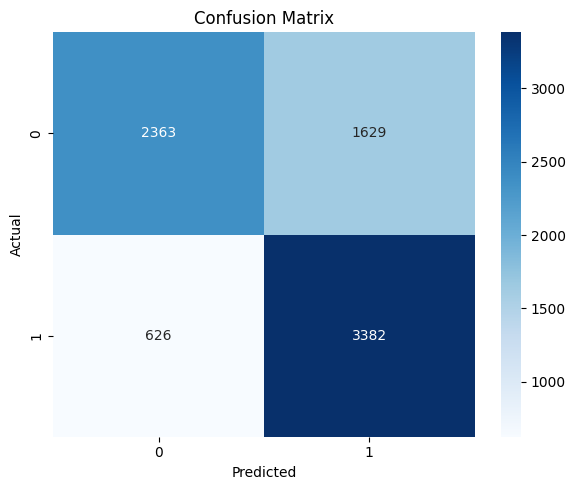

/home/michael/dev/uni/comp3850/repo/PPRL-attack-POC/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [14]:
# ====================================
# Step 5: Evaluation and Visualization
# ====================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

y_pred_prob = clf_model.predict(diff_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Classifier Accuracy:", acc)
print("Classifier F1 Score:", f1)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("outputs/figures/shadow_confusion_matrix.png")
plt.show()

# Save Model
clf_model.save("outputs/models/shadow_clf.h5")

In [10]:
print("Train label distribution:")
print(pd.Series(y_train).value_counts())


Train label distribution:
1.0    16031
0.0    15969
Name: count, dtype: int64


In [11]:
import os
os.makedirs("outputs/models", exist_ok=True)

encoder.save("outputs/models/shadow_encoder.h5")
clf_model.save("outputs/models/shadow_clf.h5")

# Also save the target's own predictions for later MIA feature extraction.
import numpy as np
np.save("outputs/models/shadow_train_probs.npy",
        clf_model.predict(np.abs(encoder.predict(x1_train) - encoder.predict(x2_train))).flatten())
np.save("outputs/models/shadow_test_probs.npy",
        clf_model.predict(np.abs(encoder.predict(x1_test) - encoder.predict(x2_test))).flatten())

print("target artifacts saved")

250/250 [==============================] - 0s 447us/step
target artifacts saved
